In [5]:
from openaq import OpenAQ as aq
import pandas as pd
import geopandas
import folium
#Load API
api = aq(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")

In [6]:
#Get the locations list for india. Limit argument is to make sure it covers all the available stations in india
locations = api.locations.list(
    countries_id=9,
    limit=1000
)

In [7]:
# Convert results to a list of dictionaries for Pandas
locs_data = [loc for loc in locations.results]
df = pd.DataFrame(locs_data)

Each entry in the sensor column is a list of dictionaries. Which looks like this

[{'id': 33,
  'name': 'co µg/m³',
  'parameter': {'id': 4,
   'name': 'co',
   'units': 'µg/m³',
   'display_name': 'CO mass'}}, 
 {'id': 32,
  'name': 'no2 µg/m³',
  'parameter': {'id': 5,
   'name': 'no2',
   'units': 'µg/m³',
   'display_name': 'NO₂ mass'}},
 {'id': 31,
  'name': 'pm10 µg/m³',
  'parameter': {'id': 1,
   'name': 'pm10',
   'units': 'µg/m³',
   'display_name': 'PM10'}},
 {'id': 34,
  'name': 'pm25 µg/m³',
  'parameter': {'id': 2,
   'name': 'pm25',
   'units': 'µg/m³',
   'display_name': 'PM2.5'}}]

In [8]:
#choosing required parameters and filtering the data for locations with all 4 parameters
required = {"co", "no2", "pm10", "pm25"}
def has_all_required(sensor_list):
    params = {s["parameter"]["name"] for s in sensor_list}
    return required.issubset(params)

filtered_df = df[df["sensors"].apply(has_all_required)]

Found 629 locations with all 4 sensors which are CO, NO2, PM2.5 and PM10

In [9]:
#An interactive map of the available locations using foleum. You might have to wait some time for it to load completely. 

filtered_df["lat"] = filtered_df["coordinates"].apply(lambda x: x["latitude"])
filtered_df["lon"] = filtered_df["coordinates"].apply(lambda x: x["longitude"])

stations = filtered_df[["name", "lat", "lon"]]

import folium

m = folium.Map(location=[22, 80], zoom_start=5)  # center on India

for _, row in stations.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        popup=row["name"],
        color="red",
        fill=True
    ).add_to(m)

m

/tmp/ipykernel_198301/4234443418.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["lat"] = filtered_df["coordinates"].apply(lambda x: x["latitude"])
/tmp/ipykernel_198301/4234443418.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["lon"] = filtered_df["coordinates"].apply(lambda x: x["longitude"])


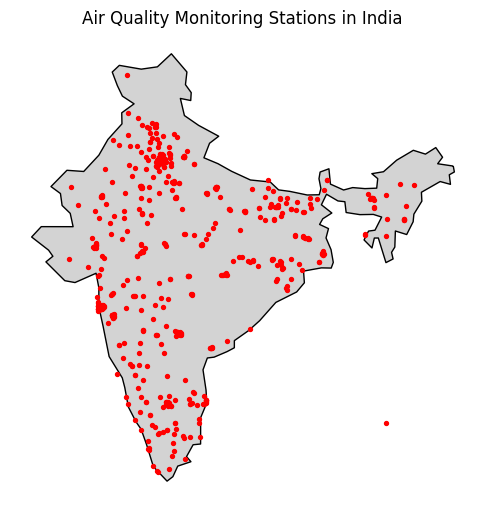

In [10]:
import geopandas as gpd
import geodatasets

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
india = world[world["ADMIN"] == "India"]

import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.lon, stations.lat),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(6,8))

india.plot(ax=ax, color="lightgray", edgecolor="black")

gdf.plot(
    ax=ax,
    color="red",
    markersize=8
)

ax.set_title("Air Quality Monitoring Stations in India")
ax.set_axis_off()

plt.show()

In [3]:
world

,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."
...,...,...,...,...
122,Land,1,1.0,"POLYGON ((51.13619 80.54728, 49.79368 80.41543..."
123,Land,0,0.0,"POLYGON ((99.93976 78.88094, 97.75794 78.7562,..."
124,Land,0,0.0,"POLYGON ((-87.02 79.66, -85.81435 79.3369, -87..."
125,Land,0,0.0,"POLYGON ((-68.5 83.10632, -65.82735 83.02801, ..."
